# 02 Training：Conditional U-Net（Python 3.12+）

Output checkpoint：`./checkpoints/best.pt`, which GUI can directly use.

In [ ]:
import sys, os
PROJECT_DIR = os.path.abspath(".")
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

from pathlib import Path
TRAIN_MANIFEST = Path("./manifests/train.json")
VAL_MANIFEST = Path("./manifests/val.json")
assert TRAIN_MANIFEST.exists() and VAL_MANIFEST.exists(), "First, run Notebook 01 to generate manifests"
print("TRAIN_MANIFEST:", TRAIN_MANIFEST.resolve())
print("VAL_MANIFEST:", VAL_MANIFEST.resolve())


TRAIN_MANIFEST: /root/autodl-tmp/Image/manifests/train.json
VAL_MANIFEST: /root/autodl-tmp/Image/manifests/val.json


In [2]:
import torch
from torch.utils.data import DataLoader

from color_points_dl.dataset import ColorPointsDataset, DataConfig
from color_points_dl.points import PointSamplerConfig
from color_points_dl.unet import UNetColorizer
from color_points_dl.train_loop import TrainConfig, LossConfig, fit
from color_points_dl.utils import seed_everything, get_device


In [3]:
seed_everything(42)

CROP_SIZE = 256
BATCH_SIZE = 8
NUM_WORKERS = 6

point_cfg = PointSamplerConfig(
    mode="random",
    k_min=int(round(0.05 * CROP_SIZE * CROP_SIZE)),
    k_max=int(round(0.15 * CROP_SIZE * CROP_SIZE)),
    radius_min=0,
    radius_max=0,
)

data_cfg = DataConfig(
    crop_size=CROP_SIZE,
    augment_hflip=True,
    augment_random_crop=True,
    crop_scale_min=0.70,

    augment_vflip=False,
    augment_rot90=False,

    augment_color_jitter=True,
    jitter_brightness=0.04,
    jitter_contrast=0.04,
    jitter_saturation=0.08,

    point_cfg=point_cfg,
)

train_ds = ColorPointsDataset(str(TRAIN_MANIFEST), data_cfg=data_cfg, seed=0, is_train=True)
val_ds = ColorPointsDataset(str(VAL_MANIFEST), data_cfg=data_cfg, seed=1, is_train=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print("train:", len(train_ds), "val:", len(val_ds))
print("hint points:", point_cfg.k_min, point_cfg.k_max)

train: 114020 val: 12669
hint points: 3277 9830


In [ ]:
seed_everything(42)

device = get_device()
print("device:", device)

model = UNetColorizer(in_channels=4, out_channels=2, base_channels=64)


RESUME_FROM = None
RESET_OPTIMIZER = False 

train_cfg = TrainConfig(
    epochs=15,
    lr=2e-4,
    weight_decay=0.0,
    log_every=50,
    grad_clip=0.0,
    save_dir="./checkpoints",
    best_name="best.pt",
    last_name="last.pt",
    resume_from=RESUME_FROM,
    reset_optimizer=RESET_OPTIMIZER,
)

loss_cfg = LossConfig(lambda_hint=0.0, tv_weight=0.0)

if RESUME_FROM:
    print(" Train from the checkpoint:", RESUME_FROM)
else:
    print("will start training from scratch")

In [ ]:
seed_everything(42)
history = fit(model, train_loader, val_loader, device, train_cfg, loss_cfg)
history


In [1]:
#Training Hiltory Visualization
import matplotlib.pyplot as plt
import json
import pandas as pd
from pathlib import Path

LOG_DIR = Path("./logs")
LOG_DIR.mkdir(parents=True, exist_ok=True)

# Save raw training history as JSON
with open(LOG_DIR / "history.json", "w") as f:
    json.dump(history, f, indent=4)


print("Saved training history:")
print(LOG_DIR / "history.json")


In [2]:
import json
import matplotlib.pyplot as plt
from pathlib import Path

LOG_DIR = Path("./logs")

plt.rcParams.update({
    "font.size": 13,
    "axes.labelsize": 14,
    "axes.titlesize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 13,
})

with open(LOG_DIR / "history.json", "r") as f:
    history = json.load(f)


train_loss = history["train_loss"]
val_loss = history["val_loss"]

epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_loss,
    marker="o",
    markersize=4.5,
    linewidth=2.2,
    label="Train Loss"
)

plt.plot(
    epochs,
    val_loss,
    marker="o",
    markersize=4.5,
    linewidth=2.2,
    label="Validation Loss"
)

plt.yscale("log", base=10)

plt.xticks([1] + list(range(2, len(train_loss) + 1, 2)))

plt.xlabel("Epoch")
plt.ylabel("Loss (Log10 Scale)")
plt.title("Training and Validation Loss")

plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper right", frameon=True)

plt.savefig(LOG_DIR / "loss_curve_log10.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved loss curve:")
print(LOG_DIR / "loss_curve_log10.png")

## Visualization：Input view / Pred / GT（Validation Set)

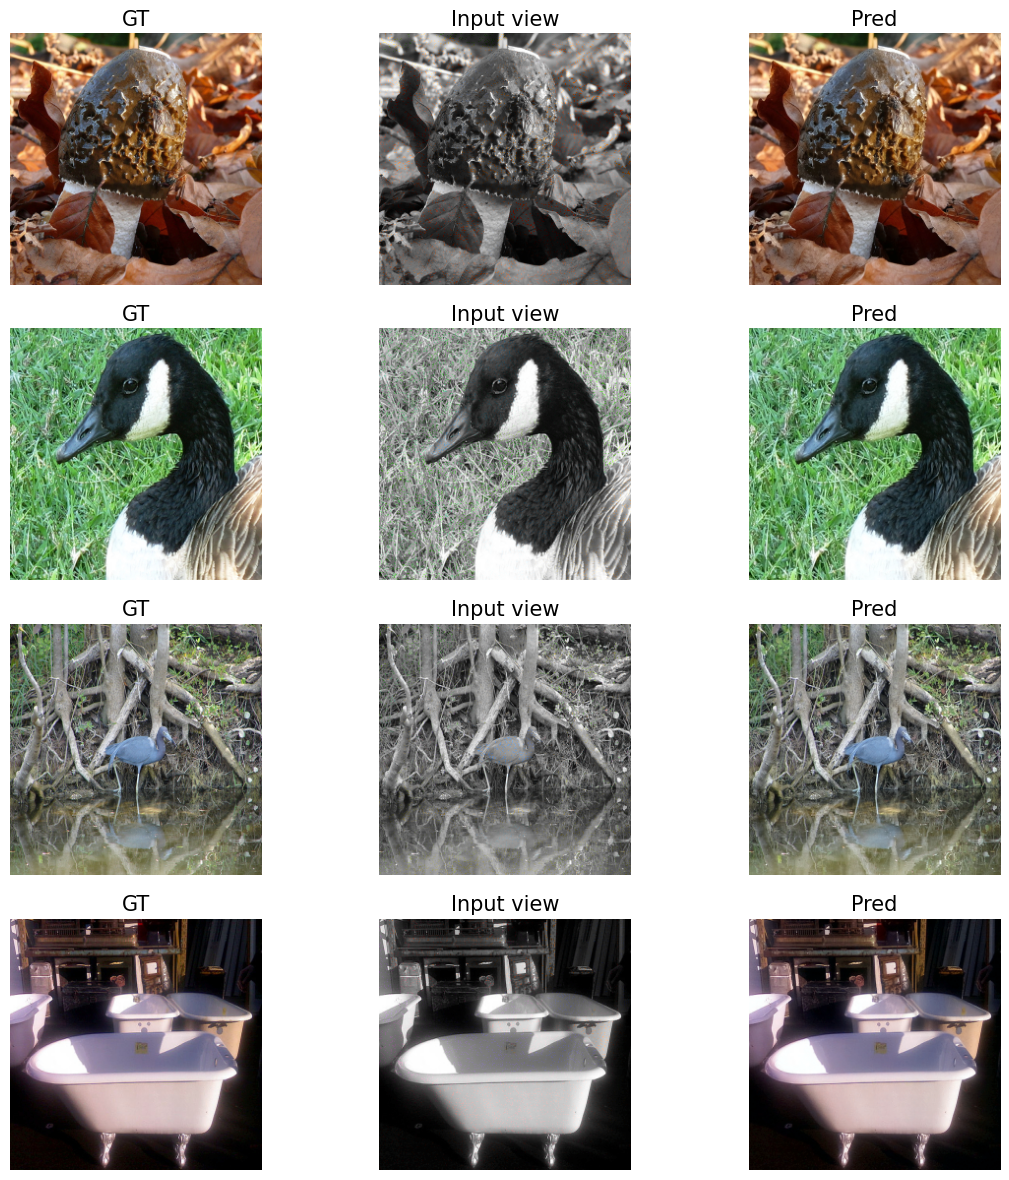

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

from color_points_dl.color_utils import lab_norm_to_bgr

@torch.no_grad()
def visualize(n=4):
    model.eval()
    batch = next(iter(val_loader))
    x = batch["x"][:n].to(device)
    y = batch["y"][:n].numpy()
    L = batch["L"][:n].numpy()
    mask = batch["mask"][:n].numpy()

    pred = model(x).cpu().numpy()
    hint_ab = batch["x"][:n, 1:3].numpy()
    m = mask.astype(bool)
    pred[m.repeat(2, axis=1)] = hint_ab[m.repeat(2, axis=1)]

    plt.figure(figsize=(12, 3*n))
    for i in range(n):
        bgr_gt = lab_norm_to_bgr(L[i], y[i])
        bgr_in = lab_norm_to_bgr(L[i], hint_ab[i])
        bgr_pr = lab_norm_to_bgr(L[i], pred[i])

        rgb_gt = cv2.cvtColor(bgr_gt, cv2.COLOR_BGR2RGB)
        rgb_in = cv2.cvtColor(bgr_in, cv2.COLOR_BGR2RGB)
        rgb_pr = cv2.cvtColor(bgr_pr, cv2.COLOR_BGR2RGB)

        plt.subplot(n,3,i*3+1); plt.imshow(rgb_gt); plt.title("GT"); plt.axis("off")
        plt.subplot(n,3,i*3+2); plt.imshow(rgb_in); plt.title("Input view"); plt.axis("off")
        plt.subplot(n,3,i*3+3); plt.imshow(rgb_pr); plt.title("Pred"); plt.axis("off")
    plt.tight_layout()
    plt.show()

visualize(4)
